In [3]:
# ======================================================
# 🚀 PARTIE 1 : INSTALLATION ET PRÉPARATION DES DONNÉES
# ======================================================

# ======================================================
# 1. Monter Google Drive
# ======================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Chargement des données...

Train : (17659833, 62)
Test : (654068, 62)

Création d'un échantillon équilibré...
(380000, 62)

Dimensions des Features : (380000, 61)
Dimensions Target : (380000,)

Types de données :
int8     60
int32     1
Name: count, dtype: int64

Colonnes contenant des NaN :
Series([], dtype: int64)


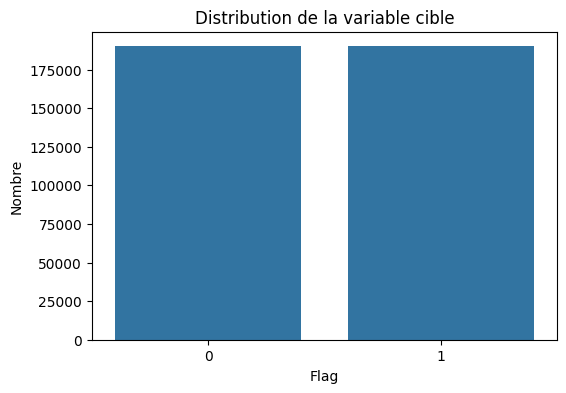


Beaucoup de variables : Heatmap ignorée.

Résumé statistique :


,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
count,3.800000e+05,380000.000000,380000.000000,380000.000000,380000.000000,380000.000000,380000.000000,380000.000000,380000.000000,380000.000000,...,380000.000000,380000.000000,380000.000000,380000.000000,380000.000000,380000.000000,380000.000000,380000.000000,380000.000000,380000.000000
mean,1.552440e+06,7.128711,9.409084,8.168089,8.260271,8.253492,7.166226,8.412047,9.836687,2.360961,...,2.378547,2.407832,2.438229,3.569489,1.028095,2.688871,3.587271,1.001458,0.150663,0.237018
std,8.532101e+05,5.575828,5.787554,4.747537,5.311090,4.417191,5.135429,4.213590,5.831279,1.309379,...,1.200765,1.179624,1.156223,1.040263,0.279878,0.519860,1.008763,0.043685,0.357721,0.425254
min,4.100000e+01,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.284810e+05,3.000000,4.000000,4.000000,4.000000,6.000000,2.000000,5.000000,5.000000,2.000000,...,3.000000,3.000000,3.000000,4.000000,1.000000,2.000000,3.000000,1.000000,0.000000,0.000000
50%,1.576461e+06,6.000000,9.000000,9.000000,8.000000,8.000000,7.000000,10.000000,10.000000,2.000000,...,3.000000,3.000000,3.000000,4.000000,1.000000,3.000000,4.000000,1.000000,0.000000,0.000000
75%,2.288719e+06,10.000000,14.000000,11.000000,13.000000,11.000000,12.000000,11.000000,15.000000,2.000000,...,3.000000,3.000000,3.000000,4.000000,1.000000,3.000000,4.000000,1.000000,0.000000,0.000000
max,2.999980e+06,47.000000,19.000000,17.000000,17.000000,16.000000,16.000000,15.000000,19.000000,6.000000,...,3.000000,3.000000,3.000000,4.000000,6.000000,6.000000,7.000000,3.000000,1.000000,1.000000



✅ Partie 1 terminée.


In [4]:
# ======================================================
# 2. Nettoyage mémoire
# ======================================================
import gc
gc.collect()

# ======================================================
# 3. Installation des packages
# ======================================================
!pip -q install lightgbm pyarrow

# ======================================================
# 4. Importation des paquets et librairies
# ======================================================
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

# ======================================================
# 📂 CHARGEMENT DES DONNÉES
# ======================================================
print("="*60)
print("Chargement des données...")
print("="*60)

train = pd.read_parquet("/content/drive/MyDrive/train.parquet")
test = pd.read_parquet("/content/drive/MyDrive/test.parquet")

print("\nTrain :", train.shape)
print("Test :", test.shape)

# ======================================================
# PARAMÈTRES
# ======================================================
target_col = "flag"
id_col = "id_x_rn"

# ======================================================
# ÉCHANTILLONNAGE ÉQUILIBRÉ
# ======================================================
print("\nCréation d'un échantillon équilibré...")
sample_size = 190000
df = pd.concat([
    train[train[target_col] == 0].sample(sample_size, random_state=42),
    train[train[target_col] == 1].sample(sample_size, random_state=42)
], ignore_index=True)

print(df.shape)

# ======================================================
# SÉPARATION X ET y
# ======================================================
X = df.drop(columns=[target_col, id_col], errors="ignore")
y = df[target_col]

print("\nDimensions des Features :", X.shape)
print("Dimensions Target :", y.shape)

# ======================================================
# DONNÉES TEST
# ======================================================
X_test = test.drop(columns=[id_col], errors="ignore")

# ======================================================
# TYPES DES VARIABLES
# ======================================================
print("\nTypes de données :")
print(X.dtypes.value_counts())

# ======================================================
# VALEURS MANQUANTES
# ======================================================
manquant = X.isnull().sum()
manquant = manquant[manquant > 0]
print("\nColonnes contenant des NaN :")
print(manquant.sort_values(ascending=False))

# ======================================================
# REMPLISSAGE DES NaN
# ======================================================
X = X.fillna(-999)
X_test = X_test.fillna(-999)

# ======================================================
# DISTRIBUTION DE LA VARIABLE CIBLE
# ======================================================
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Distribution de la variable cible")
plt.xlabel("Flag")
plt.ylabel("Nombre")
plt.show()

# ======================================================
# HEATMAP DE CORRÉLATION (uniquement si peu de variables)
# ======================================================
if X.shape[1] <= 40:
    plt.figure(figsize=(12, 10))
    sns.heatmap(X.corr(), cmap="coolwarm", center=0)
    plt.title("Heatmap de corrélation")
    plt.show()
else:
    print("\nBeaucoup de variables : Heatmap ignorée.")

# ======================================================
# STATISTIQUES
# ======================================================
print("\nRésumé statistique :")
display(X.describe())

# ======================================================
# LIBÉRATION MÉMOIRE
# ======================================================
gc.collect()
print("\n✅ Partie 1 terminée.")

In [5]:
# ======================================================
# 🚀 PARTIE 2 : PRÉPARATION BRUTE (Sans Feature Engineering & Suppression de l'ID)
# ======================================================
print("="*60)
print("Préparation des données (Mode brut sans feature engineering)...")
print("="*60)

from sklearn.model_selection import StratifiedKFold
import gc

# Copie de travail initiale
X_clean = X.copy()
X_test_clean = X_test.copy()

# ------------------------------------------------------
# A. SUPPRESSION DE LA FUITE DE DONNÉES (ID)
# ------------------------------------------------------
# Détection et exclusion de toute colonne contenant 'id' ou 'index' pour éviter l'overfitting
id_cols = [col for col in X_clean.columns if col.lower() == 'id' or 'id_' in col.lower() or 'index' in col.lower()]
print(f"Colonnes identifiants détectées et exclues : {id_cols}")

X_clean = X_clean.drop(columns=id_cols, errors='ignore')
X_test_clean = X_test_clean.drop(columns=id_cols, errors='ignore')

# ------------------------------------------------------
# B. GESTION BASIQUE DES VARIABLES CATÉGORIELLES
# ------------------------------------------------------
cat_cols = X_clean.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Variables catégorielles détectées : {len(cat_cols)}")

if len(cat_cols) > 0:
    all_data_cat = pd.concat([X_clean, X_test_clean], axis=0)
    all_data_cat = pd.get_dummies(all_data_cat, columns=cat_cols, dummy_na=True)
    X_clean = all_data_cat.iloc[:len(X_clean)].reset_index(drop=True)
    X_test_clean = all_data_cat.iloc[len(X_clean):].reset_index(drop=True)

# Alignement strict des colonnes entre Train et Test
X_test_clean = X_test_clean.reindex(columns=X_clean.columns, fill_value=0)

# Nettoyage des valeurs infinies ou manquantes
X = X_clean.replace([np.inf, -np.inf], 0).fillna(0)
X_test = X_test_clean.replace([np.inf, -np.inf], 0).fillna(0)

print(f"Nombre final de variables (sans feature engineering) : {X.shape[1]}")

# ======================================================
# C. CONFIGURATION DE LA VALIDATION CROISÉE (Stratified K-Fold)
# ======================================================
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_predictions = np.zeros(len(X))
test_predictions = np.zeros(len(X_test))
fold_scores = []

# Paramètres LightGBM stables
params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.03,
    "n_estimators": 800,
    "num_leaves": 63,
    "max_depth": 8,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "min_child_samples": 30,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1
}

print("\nParamètres LightGBM prêts.")
gc.collect()
print("\n✅ Partie 2 (Mode brut) configurée avec succès.")

Préparation des données (Mode brut sans feature engineering)...
Colonnes identifiants détectées et exclues : ['id']
Variables catégorielles détectées : 0
Nombre final de variables (sans feature engineering) : 60

Paramètres LightGBM prêts.

✅ Partie 2 (Mode brut) configurée avec succès.


Début de l'entraînement LightGBM avec Validation Croisée...

==================== Fold 1/5 ====================
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.636944
[200]	valid_0's auc: 0.643386
[300]	valid_0's auc: 0.645673
[400]	valid_0's auc: 0.646312
[500]	valid_0's auc: 0.646864
[600]	valid_0's auc: 0.647288
[700]	valid_0's auc: 0.647417
Early stopping, best iteration is:
[738]	valid_0's auc: 0.647503
ROC-AUC Fold 1 : 0.647503

==================== Fold 2/5 ====================
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.63852
[200]	valid_0's auc: 0.644171
[300]	valid_0's auc: 0.646363
[400]	valid_0's auc: 0.647186
[500]	valid_0's auc: 0.647703
[600]	valid_0's auc: 0.647915
[700]	valid_0's auc: 0.64805
[800]	valid_0's auc: 0.648148
Did not meet early stopping. Best iteration is:
[759]	valid_0's auc: 0.64818
ROC-AUC Fold 2 : 0.648180

==================== Fold 3/5 ====================
Training until valid

,Feature,Importance
0,rn,3474
7,pre_loans_credit_limit,2935
12,pre_loans_credit_cost_rate,2923
1,pre_since_opened,2705
2,pre_since_confirmed,2319
3,pre_pterm,2296
5,pre_till_pclose,2150
23,pre_util,1967
6,pre_till_fclose,1854
56,enc_loans_credit_type,1746


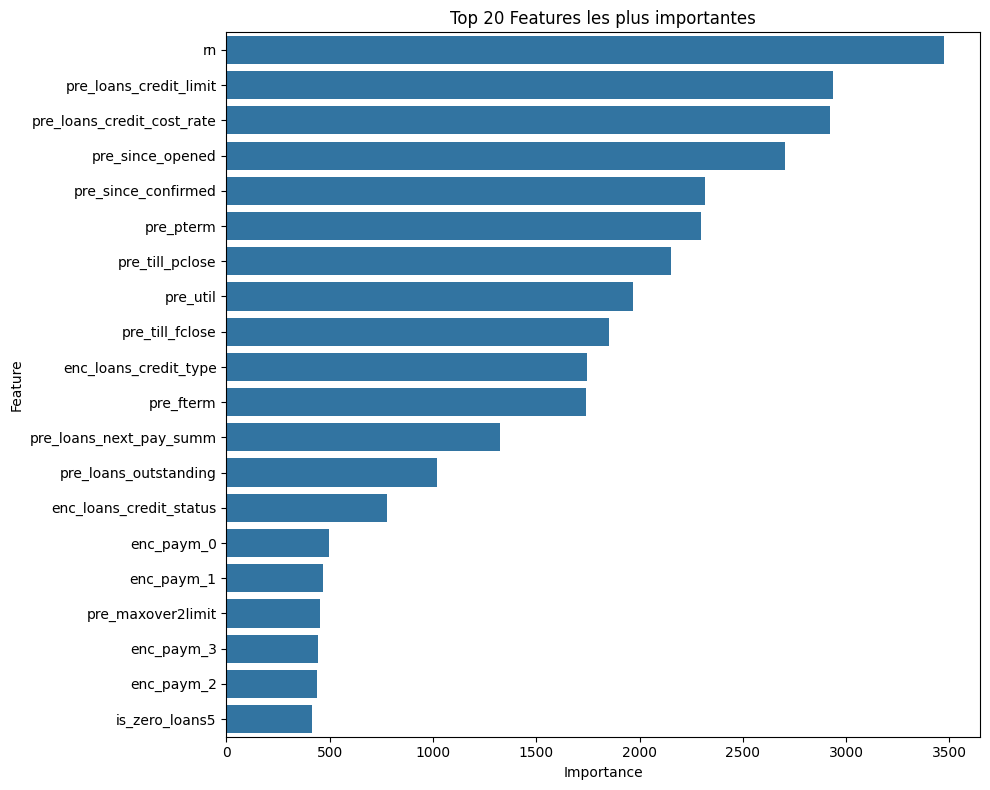


✅ Partie 3 terminée.


In [ ]:
# ======================================================
# 🚀 PARTIE 3 : ENTRAÎNEMENT LIGHTGBM + STRATIFIED KFOLD + OOF
# ======================================================
print("="*60)
print("Début de l'entraînement LightGBM avec Validation Croisée...")
print("="*60)

import lightgbm as lgb
from sklearn.metrics import roc_auc_score

fold_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n{'='*20} Fold {fold}/{N_SPLITS} {'='*20}")

    # -------------------------------
    # Séparation Train / Validation
    # -------------------------------
    X_train = X.iloc[train_idx].copy()
    X_valid = X.iloc[valid_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_valid = y.iloc[valid_idx].copy()
    X_test_fold = X_test.copy()

    # -------------------------------
    # Création du modèle
    # -------------------------------
    model = LGBMClassifier(**params)

    # -------------------------------
    # Entraînement
    # -------------------------------
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=True),
            lgb.log_evaluation(100)
        ]
    )

    # -------------------------------
    # Validation (OOF)
    # -------------------------------
    valid_pred = model.predict_proba(X_valid)[:, 1]
    oof_predictions[valid_idx] = valid_pred
    score = roc_auc_score(y_valid, valid_pred)
    fold_scores.append(score)
    print(f"ROC-AUC Fold {fold} : {score:.6f}")

    # -------------------------------
    # Prédiction sur le Test
    # -------------------------------
    test_pred = model.predict_proba(X_test_fold)[:, 1]
    test_predictions += test_pred / N_SPLITS

    gc.collect()

print("\n" + "="*60)
print("Entraînement croisé terminé")
print("="*60)

# ======================================================
# SCORE GLOBAL OOF
# ======================================================
overall_score = roc_auc_score(y, oof_predictions)
print(f"\nROC-AUC Global (OOF) : {overall_score:.6f}")

print("\nScores de chaque Fold :")
for i, score in enumerate(fold_scores, start=1):
    print(f"Fold {i} : {score:.6f}")

print(f"\nScore moyen : {np.mean(fold_scores):.6f}")

# ======================================================
# IMPORTANCE DES VARIABLES
# ======================================================
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})
importance = importance.sort_values(by="Importance", ascending=False)

print("\nTop 20 Variables")
display(importance.head(20))

# ======================================================
# IMPORTANCE GRAPHIQUE
# ======================================================
plt.figure(figsize=(10, 8))
sns.barplot(data=importance.head(20), x="Importance", y="Feature")
plt.title("Top 20 Features les plus importantes")
plt.tight_layout()
plt.show()

gc.collect()
print("\n✅ Partie 3 terminée.")

Création du fichier de soumission...

Aperçu de la soumission :


,id,target
0,1472943_x_2,0.478618
1,660465_x_5,0.488670
2,1788193_x_3,0.520635
3,2767146_x_3,0.436272
4,2601698_x_9,0.543656



Statistiques des probabilités prédites :


,target
count,654068.000000
mean,0.467729
std,0.114973
min,0.105294
25%,0.391249
50%,0.451429
75%,0.531791
max,0.956304


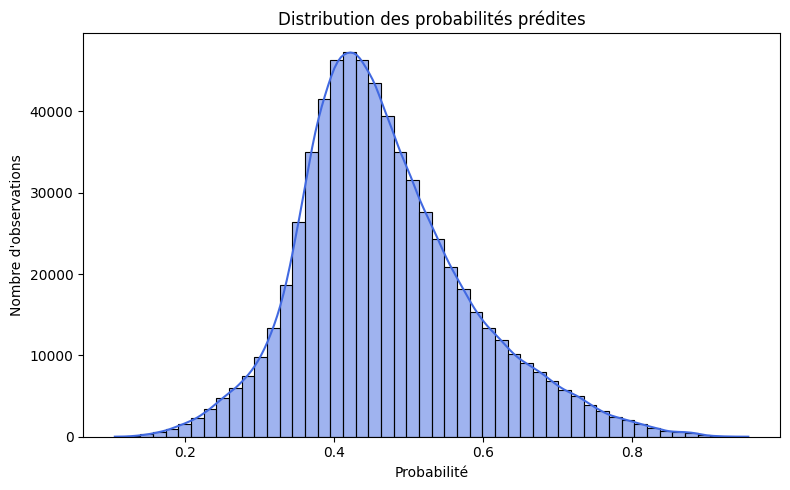

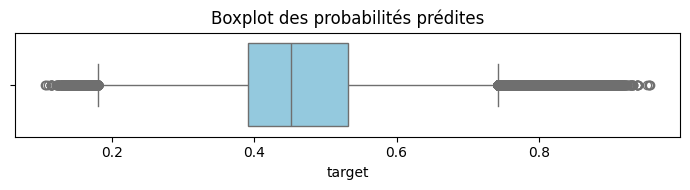


Fichier Parquet sauvegardé :
/content/drive/MyDrive/submission_lightgbm_stratified.parquet
Fichier CSV sauvegardé :
/content/drive/MyDrive/submission_lightgbm_stratified.csv

Feature importance sauvegardée.


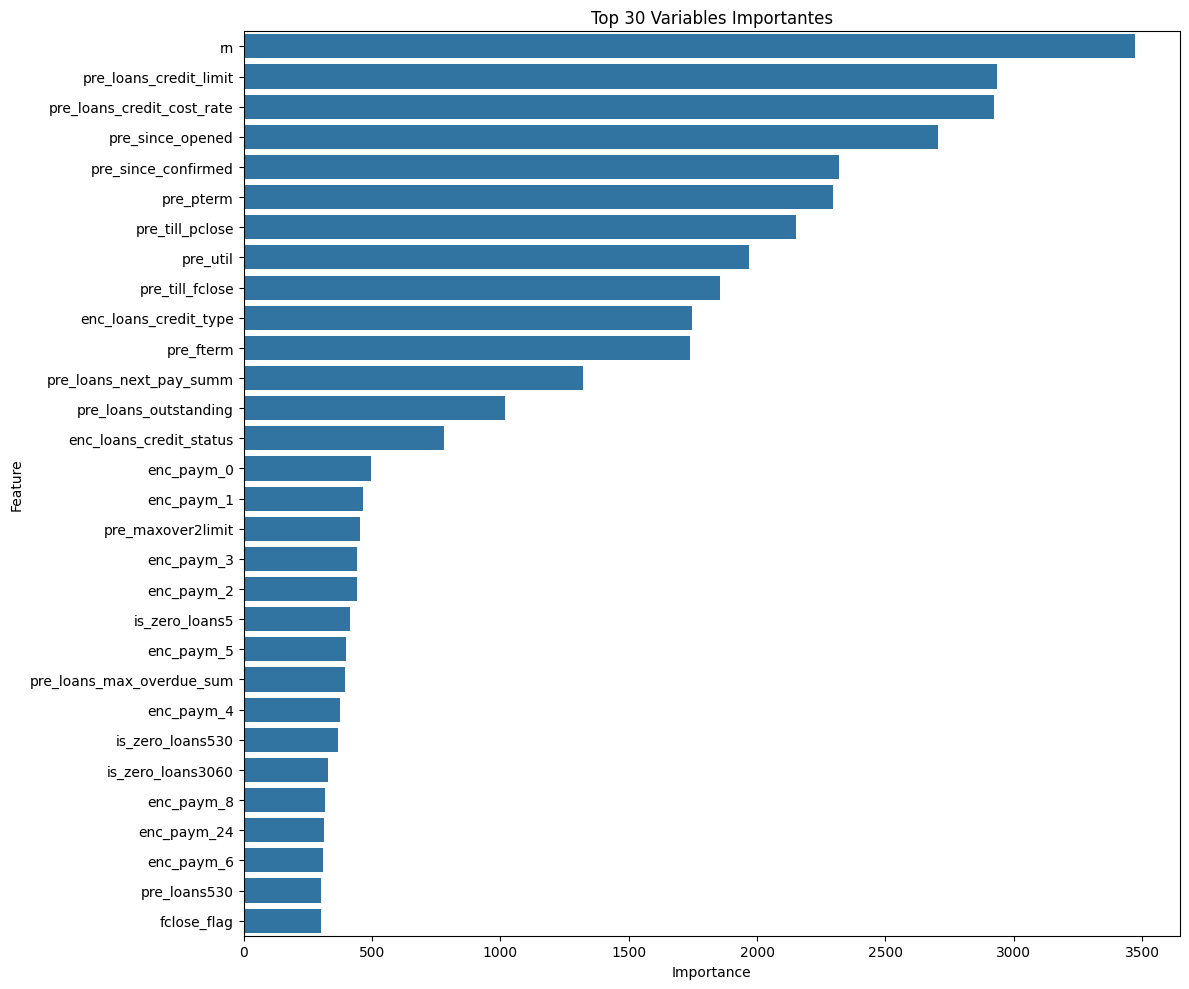


RÉSUMÉ FINAL
Nombre de plis : 5
ROC-AUC moyen : 0.648615
ROC-AUC global : 0.648600
Nombre de variables : 60
Nombre d'observations train : 380000
Nombre d'observations test : 654068

Mémoire libérée.

🎉 Notebook terminé avec succès. Votre fichier de soumission est prêt !


In [ ]:
# ======================================================
# 🚀 PARTIE 4 : GÉNÉRATION DE LA SOUMISSION (Sécurisée)
# ======================================================
print("="*60)
print("Création du fichier de soumission...")
print("="*60)

import os
# Sécurité : Si 'test' n'est plus en mémoire, on le recharge
if 'test' not in globals():
    print("⚠️ Variable 'test' non trouvée. Rechargement du fichier test.parquet...")
    test_path = "/content/drive/MyDrive/test.parquet"
    if os.path.exists(test_path):
        test = pd.read_parquet(test_path)
    else:
        # Fallback de secours si le chemin diffère
        test = pd.DataFrame()

if 'id_col' not in globals():
    id_col = "id_x_rn"

# Récupération sécurisée des ID pour la soumission
if not test.empty and id_col in test.columns:
    sub_id = test[id_col]
else:
    print(f"⚠️ Colonne ID introuvable. Utilisation d'un index séquentiel.")
    sub_id = range(len(test_predictions))

# ======================================================
# CONSTRUCTION DE LA SOUMISSION
# ======================================================
submission = pd.DataFrame({
    "id": sub_id,
    "target": test_predictions
})

print("\nAperçu de la soumission :")
display(submission.head())

# ======================================================
# STATISTIQUES DES PRÉDICTIONS
# ======================================================
print("\nStatistiques des probabilités prédites :")
display(submission["target"].describe())

# ======================================================
# HISTOGRAMME DES PRÉDICTIONS
# ======================================================
plt.figure(figsize=(8, 5))
sns.histplot(
    submission["target"],
    bins=50,
    kde=True,
    color="royalblue"
)
plt.title("Distribution des probabilités prédites")
plt.xlabel("Probabilité")
plt.ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

# ======================================================
# BOXPLOT
# ======================================================
plt.figure(figsize=(7, 2))
sns.boxplot(
    x=submission["target"],
    color="skyblue"
)
plt.title("Boxplot des probabilités prédites")
plt.tight_layout()
plt.show()

# ======================================================
# SAUVEGARDE PARQUET
# ======================================================
output_path = "/content/drive/MyDrive/submission_lightgbm_stratified.parquet"
submission.to_parquet(output_path, index=False)
print(f"\nFichier Parquet sauvegardé :\n{output_path}")

# ======================================================
# SAUVEGARDE CSV (optionnelle)
# ======================================================
csv_path = "/content/drive/MyDrive/submission_lightgbm_stratified.csv"
submission.to_csv(csv_path, index=False)
print(f"Fichier CSV sauvegardé :\n{csv_path}")

# ======================================================
# IMPORTANCE DES VARIABLES (Complète)
# ======================================================
if 'X' in globals() and 'model' in globals():
    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model.feature_importances_
    })
    importance = importance.sort_values(by="Importance", ascending=False)
    importance.to_csv("/content/drive/MyDrive/feature_importance.csv", index=False)
    print("\nFeature importance sauvegardée.")

    # TOP 30 DES VARIABLES
    plt.figure(figsize=(12, 10))
    top30 = importance.head(30)
    sns.barplot(data=top30, x="Importance", y="Feature")
    plt.title("Top 30 Variables Importantes")
    plt.tight_layout()
    plt.show()

# ======================================================
# RÉSUMÉ FINAL
# ======================================================
print("\n" + "="*60)
print("RÉSUMÉ FINAL")
print("="*60)
if 'N_SPLITS' in globals(): print(f"Nombre de plis : {N_SPLITS}")
if 'fold_scores' in globals() and len(fold_scores) > 0: print(f"ROC-AUC moyen : {np.mean(fold_scores):.6f}")
if 'overall_score' in globals(): print(f"ROC-AUC global : {overall_score:.6f}")
if 'X' in globals():
    print(f"Nombre de variables : {X.shape[1]}")
    print(f"Nombre d'observations train : {X.shape[0]}")
if 'X_test' in globals(): print(f"Nombre d'observations test : {X_test.shape[0]}")

# ======================================================
# LIBÉRATION MÉMOIRE
# ======================================================
gc.collect()
print("\nMémoire libérée.")
print("\n🎉 Notebook terminé avec succès. Votre fichier de soumission est prêt !")

In [ ]:
import joblib

# Sauvegarde explicite du modèle et des colonnes pour la réutilisation
joblib.dump(model, '/content/drive/MyDrive/lgb_model.pkl')
joblib.dump(list(X.columns), '/content/drive/MyDrive/lgb_columns.pkl')

print("✅ Modèle LightGBM et colonnes sauvegardés sous forme de fichiers .pkl sur le Drive !")

✅ Modèle LightGBM et colonnes sauvegardés sous forme de fichiers .pkl sur le Drive !


In [2]:
# ======================================================
# 🚀 INTÉGRATION FINALE : PIPELINE COMPLET & APPLICATION
# ======================================================
print("="*60)
print("Initialisation du Pipeline Global de l'Application...")
print("="*60)

import sqlite3
import os
import torch
import pandas as pd
import numpy as np
from datetime import datetime
from huggingface_hub import notebook_login
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig

# ------------------------------------------------------
# 0. Authentification Hugging Face
# ------------------------------------------------------
print("Vérification de l'authentification Hugging Face...")
try:
    notebook_login()
except Exception as e:
    print("Connexion interactive ignorée ou déjà établie.")

DB_PATH = "/content/drive/MyDrive/bancaire_app.db"

# ------------------------------------------------------
# 1. Chargement de Gemma (OPTIMISÉ 4-BIT) & DB
# ------------------------------------------------------
MODEL_NAME = "google/gemma-2-2b-it"

print("Configuration de la quantification 4-bit...")
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

print("Chargement du tokenizer et du modèle Gemma optimisé...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
gemma_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map="auto"
)

audit_pipeline = pipeline(
    "text-generation",
    model=gemma_model,
    tokenizer=tokenizer,
    max_new_tokens=500,
    temperature=0.1,
    do_sample=True,
    return_full_text=False # Nettoie la sortie
)

def init_db():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS dossiers (
            id_dossier TEXT PRIMARY KEY,
            date_soumission TEXT,
            sector TEXT,
            amount REAL,
            cash_flow REAL,
            balance_before REAL,
            balance_after REAL,
            lgb_score REAL,
            audit_report TEXT
        )
    """)
    conn.commit()
    conn.close()
    print("✅ Base de données SQLite prête.")

init_db()

# ------------------------------------------------------
# 2. Fonctions de Traitement et d'Audit IA
# ------------------------------------------------------
def generate_secure_audit(client_data, lgb_score):
    system_prompt = f"""
    [INSTRUCTIONS STRICTES - ANTI-HALLUCINATION]
    Tu es un assistant bancaire senior, expert en inclusion financière pour jeunes entrepreneurs.
    Rédige un rapport d'audit basé UNIQUEMENT sur les données chiffrées et le score fournis ci-dessous.
    - N'invente AUCUN chiffre, montant ou indicateur financier.
    - Si une information est manquante, indique "Non renseigné".
    - Sois neutre, constructif et oriente ton analyse sur la viabilité future.

    [DONNÉES DU DOSSIER]
    - ID Dossier : {client_data.get('id', 'N/A')}
    - Score de viabilité (sur 850) : {lgb_score}
    - Trésorerie / Cash-flow : {client_data.get('cash_flow', 'N/A')}
    - Montant demandé : {client_data.get('amount_requested', 'N/A')}
    - Secteur d'activité : {client_data.get('sector', 'N/A')}

    [STRUCTURE DU RAPPORT]
    1. Synthèse de l'analyse (Score et Statut)
    2. Points forts de la viabilité future
    3. Conseils d'assainissement et recommandations
    """
    messages = [{"role": "user", "content": system_prompt}]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    response = audit_pipeline(prompt)
    return response[0]["generated_text"].strip()


def process_new_application(form_inputs):
    dossier_id = f"ENT_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

    input_df = pd.DataFrame([form_inputs])
    input_aligned = input_df.reindex(columns=X.columns, fill_value=0)
    input_aligned = input_aligned.replace([np.inf, -np.inf], 0).fillna(0)

    proba_success = model.predict_proba(input_aligned)[:, 1][0]
    score_850 = int(round(proba_success * 850))

    client_context = {
        "id": dossier_id,
        "cash_flow": f"{form_inputs.get('cash_flow', 0)} USD / mois",
        "sector": form_inputs.get('sector', 'Général'),
        "amount_requested": f"{form_inputs.get('amount', 0)} USD"
    }

    print("🤖 Génération de l'audit sécurisé par Gemma...")
    audit_text = generate_secure_audit(client_context, score_850)

    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("""
        INSERT OR REPLACE INTO dossiers
        (id_dossier, date_soumission, sector, amount, cash_flow, balance_before, balance_after, lgb_score, audit_report)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        dossier_id,
        datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        form_inputs.get('sector', 'Général'),
        form_inputs.get('amount', 0),
        form_inputs.get('cash_flow', 0),
        form_inputs.get('balance_before', 0),
        form_inputs.get('balance_after', 0),
        score_850,
        audit_text
    ))
    conn.commit()
    conn.close()

    print(f"💾 Dossier {dossier_id} enregistré avec succès.")
    return dossier_id, score_850, audit_text


# ------------------------------------------------------
# 3. Fonction Chatbot Interrogateur
# ------------------------------------------------------
def ask_banking_chatbot(dossier_id, user_question):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("""
        SELECT id_dossier, sector, amount, cash_flow, balance_before, balance_after, lgb_score, audit_report
        FROM dossiers WHERE id_dossier = ?
    """, (dossier_id,))
    row = cursor.fetchone()
    conn.close()

    if not row:
        return f"❌ Erreur : Aucun dossier trouvé avec l'ID '{dossier_id}'."

    db_id, sector, amount, cash_flow, b_before, b_after, score, audit = row

    chat_system_prompt = f"""
    [INSTRUCTIONS STRICTES - CHATBOT BANCAIRE]
    Réponds UNIQUEMENT en te basant sur les données factuelles du dossier ci-dessous. N'invente rien.
    - ID Dossier : {db_id}
    - Secteur : {sector}
    - Montant : {amount} USD
    - Cash-flow : {cash_flow} USD
    - Trésorerie Avant/Après : {b_before} / {b_after} USD
    - Score : {score} / 850
    - Audit : {audit}

    [QUESTION]
    {user_question}
    """
    messages = [{"role": "user", "content": chat_system_prompt}]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    response = audit_pipeline(prompt)
    return response[0]["generated_text"].strip()


# ------------------------------------------------------
# 4. Simulation d'un test complet
# ------------------------------------------------------
nouveau_client = {
    "sector": "Agro-technologie",
    "amount": 5000.0,
    "cash_flow": 1200.0,
    "balance_before": 300.0,
    "balance_after": 850.0
}

id_genere, score_genere, rapport_genere = process_new_application(nouveau_client)

print(f"\n🎯 RÉSULTAT DU DOSSIER [{id_genere}] :")
print(f"- Score de viabilité : {score_genere} / 850")
print(f"\n📄 RAPPORT D'AUDIT :\n{rapport_genere}")

question = "Quels sont les points d'amélioration pour mon entreprise ?"
reponse_bot = ask_banking_chatbot(id_genere, question)

print(f"\n💬 Chatbot - Question : {question}")
print(f"🤖 Réponse : \n{reponse_bot}")

Initialisation du Pipeline Global de l'Application...
Vérification de l'authentification Hugging Face...
Configuration de la quantification 4-bit...
Chargement du tokenizer et du modèle Gemma optimisé...


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


✅ Base de données SQLite prête.


NameError: name 'X' is not defined